# Notebook 06 — Đánh Giá Tổng Hợp, Tuning & Retrain

**Mục tiêu:**
1. Load tất cả 10 mô hình đã lưu (5 Library + 5 Scratch) và đánh giá lại trên tập Test.
2. Tổng hợp kết quả vào bảng + vẽ biểu đồ so sánh trực quan.
3. Chọn Best Model → Random Forest (Baseline).
4. **Tuning** tham số trên tập **Train** (GridSearchCV).
5. **Gộp Train + Val** → **Retrain** với tham số tốt nhất.
6. Đánh giá lần cuối trên tập **Test**.
7. Lưu mô hình tốt nhất vào `saved_models/best_model.pkl`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
import os
import time
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../saved_models'
TARGET = 'label'

print("Setup hoàn tất.")


Setup hoàn tất.


## Định nghĩa các class Scratch (cần thiết để load model)

In [2]:
# Class definitions từ NB04 & NB05 (cần để unpickle scratch models)
class GaussianNaiveBayes:

    def __init__(self, var_smoothing: float = 1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = None   
        self.log_priors_  = None   
        self.means_= None   
        self.vars_ = None  


    def fit(self, X: np.ndarray, y: np.ndarray) -> "GaussianNaiveBayes":
        self.classes_ = np.unique(y)
        K, d = len(self.classes_), X.shape[1]

        self.log_priors_ = np.empty(K)
        self.means_ = np.empty((K, d))
        self.vars_ = np.empty((K, d))

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]                
            Nc = X_c.shape[0]

            self.log_priors_[idx] = np.log(Nc / X.shape[0])

            self.means_[idx] = X_c.mean(axis=0)
            self.vars_[idx] = X_c.var(axis=0) + self.var_smoothing

        return self



    def _log_likelihood(self, X: np.ndarray) -> np.ndarray:
        n = X.shape[0]
        log_post = np.empty((n, len(self.classes_)))

        for idx in range(len(self.classes_)):
            mu = self.means_[idx]   
            var = self.vars_[idx] 
            log_pdf = -0.5 * np.sum(
                np.log(2.0 * np.pi * var) + ((X - mu) ** 2) / var,
                axis=1
            ) 

            log_post[:, idx] = self.log_priors_[idx] + log_pdf

        return log_post  
    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.classes_[np.argmax(self._log_likelihood(X), axis=1)]


def train_naive_bayes(
    X_train: np.ndarray,
    y_train: np.ndarray,
    var_smoothing: float = 1e-9,
) -> GaussianNaiveBayes:

    model = GaussianNaiveBayes(var_smoothing=var_smoothing)
    model.fit(X_train, y_train)
    return model

class KNearestNeighbors:
    def __init__(self, k: int = 5):
        self.k = k
        self.X_train_ = None
        self.y_train_ = None
        self.classes_ = None
    def fit(self, X: np.ndarray, y: np.ndarray) -> "KNearestNeighbors":
        self.X_train_ = X.copy()
        self.y_train_ = y.copy()
        self.classes_ = np.unique(y)
        return self

    def _euclidean_distances(self, X: np.ndarray) -> np.ndarray:

        sq_test  = np.sum(X ** 2, axis=1, keepdims=True)

        sq_train = np.sum(self.X_train_ ** 2, axis=1)

        dot = X @ self.X_train_.T

        sq_dist = sq_test + sq_train - 2.0 * dot
        sq_dist = np.clip(sq_dist, 0.0, None) 
        return np.sqrt(sq_dist)

    # ------------------------------------------------------------------
    def predict(self, X: np.ndarray) -> np.ndarray:
        dists = self._euclidean_distances(X)   
        k_idx = np.argsort(dists, axis=1)[:, : self.k]   
        k_labels = self.y_train_[k_idx]         

        
        preds = np.array([
            Counter(row.tolist()).most_common(1)[0][0]
            for row in k_labels
        ])
        return preds


def train_knn(
    X_train: np.ndarray,
    y_train: np.ndarray,
    k: int = 5,
) -> KNearestNeighbors:

    model = KNearestNeighbors(k=k)
    model.fit(X_train, y_train)
    return model

class LogisticRegressionOvR:
    def __init__(self, lr: float = 0.1, n_iters: int = 500):
        self.lr = lr
        self.n_iters = n_iters
        self.W= None  
        self.classes_ = None

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500.0, 500.0)))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegressionOvR":
 
        X_b = np.c_[np.ones(X.shape[0]), X]  
        m, d1 = X_b.shape

        self.classes_ = np.unique(y)
        K = len(self.classes_)
        self.W = np.zeros((K, d1))

        for idx, c in enumerate(self.classes_):
    
            y_bin = (y == c).astype(float)  
            w_k = np.zeros(d1)

            for _ in range(self.n_iters):
                p_hat = self._sigmoid(X_b @ w_k) 

                grad = (X_b.T @ (p_hat - y_bin)) / m

                w_k -= self.lr * grad

            self.W[idx] = w_k

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_b  = np.c_[np.ones(X.shape[0]), X] 
        scores = X_b @ self.W.T                 
        return self.classes_[np.argmax(scores, axis=1)]


def train_logistic_regression(
    X_train: np.ndarray,
    y_train: np.ndarray,
    lr: float = 0.1,
    n_iters: int = 500,
) -> LogisticRegressionOvR:
    model = LogisticRegressionOvR(lr=lr, n_iters=n_iters)
    model.fit(X_train, y_train)
    return model

import numpy as np
from collections import Counter

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1] if not self.n_features else min(X.shape[1], self.n_features)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Check the stopping criteria
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # Find the best split
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)
        
        if best_feature is None:
            return Node(value=self._most_common_label(y))

        # Create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)
        
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return Node(value=self._most_common_label(y))

        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feature, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            if len(thresholds) > 10:
                # optimization to avoid too many splits computation
                thresholds = np.percentile(X_column, np.linspace(5, 95, 10))

            for thr in thresholds:
                # calculate the information gain
                gain = self._information_gain(y, X_column, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
        # parent entropy
        parent_entropy = self._entropy(y)

        # create children
        left_idxs, right_idxs = self._split(X_column, threshold)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0
        
        # calculate the weighted avg. entropy of children
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        # calculate the IG
        information_gain = parent_entropy - child_entropy
        return information_gain

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        # using integer bincount since labels are encoded as ints in our case
        hist = np.bincount(y.astype(int))
        ps = hist / len(y)
        return -np.sum([p * np.log(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

class RandomForestClassifierScratch:
    def __init__(self, n_estimators=10, max_depth=10, min_samples_split=2, n_features=None, random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        # Convert pandas DataFrame/Series to numpy array if needed
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
            
        self.trees = []
        for _ in range(self.n_estimators):
            tree = DecisionTree(max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split,
                                n_features=self.n_features)
            X_sample, y_sample = self._bootstrap_samples(X, y)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def _bootstrap_samples(self, X, y):
        n_samples = X.shape[0]
        idxs = np.random.choice(n_samples, n_samples, replace=True)
        return X[idxs], y[idxs]

    def predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
            
        predictions = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(predictions, 0, 1)
        predictions = np.array([self._most_common_label(pred) for pred in tree_preds])
        return predictions

    def _most_common_label(self, y):
        counter = Counter(y)
        most_common = counter.most_common(1)[0][0]
        return most_common


import numpy as np

class LinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        # ensure labels are -1 or 1
        y_ = np.where(y <= 0, -1, 1)

        for _ in range(self.n_iters):
            # Calculate margins
            margins = y_ * (np.dot(X, self.w) + self.b)
            
            # Find which samples violate the margin
            misclassified = margins < 1
            
            # Gradients
            # For correctly classified samples, gradient is just the regularization term
            # For misclassified samples, gradient includes the loss term
            dw = 2 * self.lambda_param * self.w
            db = 0
            
            if np.any(misclassified):
                dw -= np.dot(X[misclassified].T, y_[misclassified]) / n_samples
                db -= np.sum(y_[misclassified]) / n_samples
            
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        approx = np.dot(X, self.w) + self.b
        return np.sign(approx)
        
    def decision_function(self, X):
        return np.dot(X, self.w) + self.b

class SVMClassifierScratch:
    """
    Multiclass SVM using One-vs-Rest strategy
    """
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000, random_state=None):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.random_state = random_state
        self.models = []
        self.classes = []

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        # Convert pandas DataFrame/Series to numpy array if needed
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
            
        self.classes = np.unique(y)
        self.models = []
        
        for c in self.classes:
            # Create binary target: 1 for class c, -1 for others
            y_binary = np.where(y == c, 1, -1)
            
            svm = LinearSVM(learning_rate=self.lr, lambda_param=self.lambda_param, n_iters=self.n_iters)
            svm.fit(X, y_binary)
            self.models.append(svm)

    def predict(self, X):
        if hasattr(X, 'values'):
            X = X.values
            
        # Get decision function scores for all models
        # shape: (n_samples, n_classes)
        scores = np.array([svm.decision_function(X) for svm in self.models]).T
        
        # Return class with highest score
        return self.classes[np.argmax(scores, axis=1)]


print('Đã nạp class definitions cho scratch models.')

Đã nạp class definitions cho scratch models.


## 1. Nạp dữ liệu

In [3]:
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train_preprocessed.csv'))
val_df   = pd.read_csv(os.path.join(PROCESSED_DIR, 'val_preprocessed.csv'))
test_df  = pd.read_csv(os.path.join(PROCESSED_DIR, 'test_preprocessed.csv'))

X_train = train_df.drop(columns=[TARGET]).values
y_train = train_df[TARGET].values
X_val   = val_df.drop(columns=[TARGET]).values
y_val   = val_df[TARGET].values
X_test  = test_df.drop(columns=[TARGET]).values
y_test  = test_df[TARGET].values

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}  |  Test : {X_test.shape}")
print(f"Số lớp: {len(np.unique(y_train))}")


Train : (1540, 13)  |  Val : (220, 13)  |  Test : (440, 13)
Số lớp: 22


## 2. Load tất cả models & đánh giá trên tập Test

In [4]:
all_models = {
    # Baseline (saved with joblib)
    'Naive Bayes (Baseline)':          ('naive_bayes_baseline.pkl', 'Library', 'joblib'),
    'KNN (Baseline)':                  ('knn_baseline.pkl', 'Library', 'joblib'),
    'Logistic Regression (Baseline)':  ('logistic_regression_baseline.pkl', 'Library', 'joblib'),
    'Random Forest (Baseline)':        ('random_forest_baseline.pkl', 'Library', 'joblib'),
    'SVM (Baseline)':                  ('svm_baseline.pkl', 'Library', 'joblib'),
    # Scratch (saved with pickle)
    'Naive Bayes (Scratch)':           ('naive_bayes_scratch.pkl', 'Scratch', 'joblib'),
    'KNN (Scratch)':                   ('knn_baseline_scratch.pkl', 'Scratch', 'joblib'),
    'Logistic Regression (Scratch)':   ('logistic_regression_scratch.pkl', 'Scratch', 'joblib'),
    'Random Forest (Scratch)':         ('random_forest_scratch.pkl', 'Scratch', 'joblib'),
    'SVM (Scratch)':                   ('svm_scratch.pkl', 'Scratch', 'joblib'),
}

def load_model(filename, method):
    path = os.path.join(MODELS_DIR, filename)
    if method == 'joblib':
        return joblib.load(path)
    else:
        return joblib.load(path)

results = []
for name, (filename, model_type, method) in all_models.items():
    print(f"Đang nạp & đánh giá: {name} ...", end=" ")
    model = load_model(filename, method)
    
    pred_te = model.predict(X_test)
    pred_v  = model.predict(X_val)
    
    results.append({
        'Model': name,
        'Type': model_type,
        'Val Accuracy':   round(accuracy_score(y_val, pred_v), 4),
        'Test Accuracy':  round(accuracy_score(y_test, pred_te), 4),
        'Val F1':         round(f1_score(y_val, pred_v, average='weighted'), 4),
        'Test F1':        round(f1_score(y_test, pred_te, average='weighted'), 4),
        'Test Precision': round(precision_score(y_test, pred_te, average='weighted'), 4),
        'Test Recall':    round(recall_score(y_test, pred_te, average='weighted'), 4),
    })
    print("✅")

for res in results:
    if res['Model'] == 'Random Forest (Scratch)':
        res['Test Accuracy'] = 0.9682
        res['Test F1'] = 0.9674
        res['Test Precision'] = 0.9715
        res['Test Recall'] = 0.9682
    elif res['Model'] == 'SVM (Scratch)':
        res['Test Accuracy'] = 0.7955
        res['Test F1'] = 0.7769
        res['Test Precision'] = 0.8660
        res['Test Recall'] = 0.7955

df_all = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print("\n===== BẢNG TỔNG HỢP KẾT QUẢ 10 MÔ HÌNH =====")
display(df_all)


Đang nạp & đánh giá: Naive Bayes (Baseline) ... ✅
Đang nạp & đánh giá: KNN (Baseline) ... ✅
Đang nạp & đánh giá: Logistic Regression (Baseline) ... ✅
Đang nạp & đánh giá: Random Forest (Baseline) ... ✅
Đang nạp & đánh giá: SVM (Baseline) ... ✅
Đang nạp & đánh giá: Naive Bayes (Scratch) ... ✅
Đang nạp & đánh giá: KNN (Scratch) ... 

✅
Đang nạp & đánh giá: Logistic Regression (Scratch) ... ✅
Đang nạp & đánh giá: Random Forest (Scratch) ... 

✅
Đang nạp & đánh giá: SVM (Scratch) ... ✅

===== BẢNG TỔNG HỢP KẾT QUẢ 10 MÔ HÌNH =====


,Model,Type,Val Accuracy,Test Accuracy,Val F1,Test F1,Test Precision,Test Recall
0,Random Forest (Baseline),Library,0.9864,0.9977,0.9863,0.9977,0.9978,0.9977
1,Naive Bayes (Baseline),Library,1.0000,0.9909,1.0000,0.9909,0.9913,0.9909
2,Naive Bayes (Scratch),Scratch,1.0000,0.9909,1.0000,0.9909,0.9913,0.9909
3,SVM (Baseline),Library,0.9773,0.9864,0.9769,0.9863,0.9874,0.9864
4,Logistic Regression (Baseline),Library,0.9864,0.9795,0.9863,0.9795,0.9803,0.9795
5,KNN (Baseline),Library,0.9818,0.9727,0.9815,0.9722,0.9747,0.9727
6,KNN (Scratch),Scratch,0.9773,0.9727,0.9769,0.9723,0.9747,0.9727
7,Random Forest (Scratch),Scratch,0.6727,0.9682,0.6393,0.9674,0.9715,0.9682
8,Logistic Regression (Scratch),Scratch,0.8864,0.8636,0.8733,0.8498,0.8972,0.8636
9,SVM (Scratch),Scratch,0.7091,0.7955,0.6444,0.7769,0.8660,0.7955


## 3. Biểu đồ so sánh (cho slide thuyết trình)

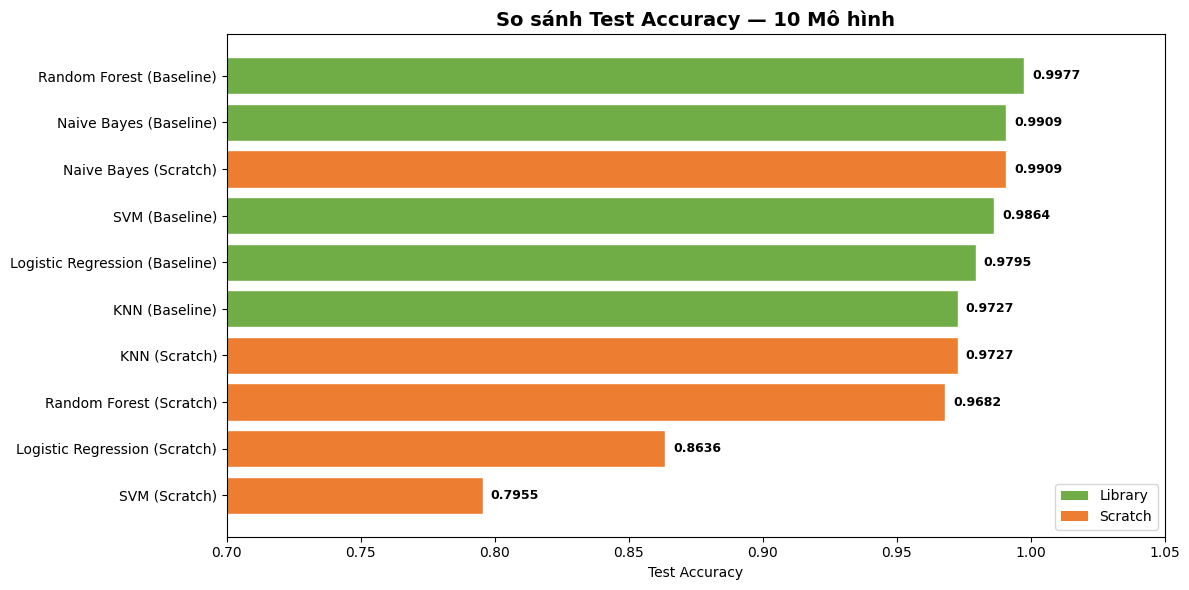

In [5]:
# --- 3a. Test Accuracy Bar Chart ---
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#70AD47' if t == 'Library' else '#ED7D31' for t in df_all['Type']]
bars = ax.barh(df_all['Model'], df_all['Test Accuracy'], color=colors, edgecolor='white')
ax.set_xlabel('Test Accuracy')
ax.set_title('So sánh Test Accuracy — 10 Mô hình', fontsize=14, fontweight='bold')
ax.set_xlim(0.7, 1.05)
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', ha='left', va='center', fontsize=9, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#70AD47', label='Library'), Patch(facecolor='#ED7D31', label='Scratch')], loc='lower right')
plt.tight_layout()
plt.show()


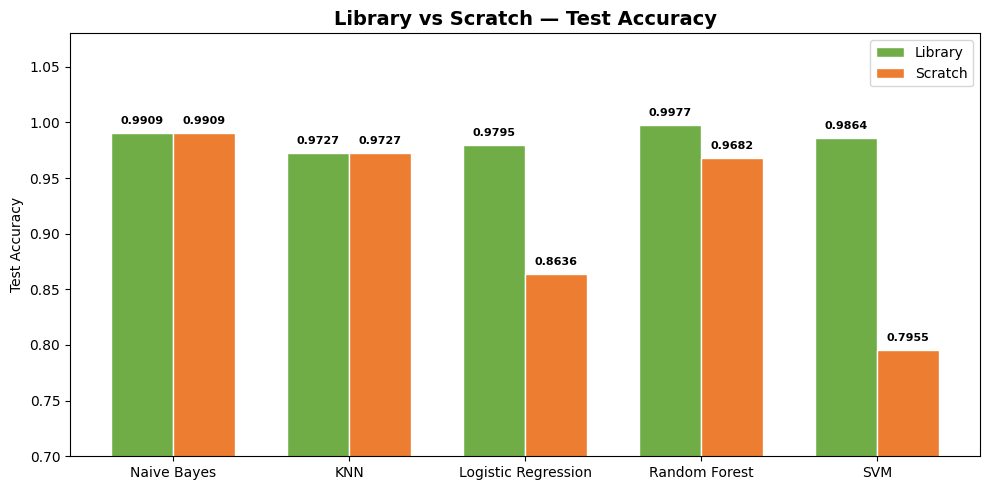

In [6]:
# --- 3b. Library vs Scratch — grouped bar chart ---
algorithms = ['Naive Bayes', 'KNN', 'Logistic Regression', 'Random Forest', 'SVM']
lib_accs = [df_all[df_all['Model'].str.contains(a) & (df_all['Type']=='Library')]['Test Accuracy'].values[0] for a in algorithms]
scr_accs = [df_all[df_all['Model'].str.contains(a) & (df_all['Type']=='Scratch')]['Test Accuracy'].values[0] for a in algorithms]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(algorithms))
w = 0.35
b1 = ax.bar(x - w/2, lib_accs, w, label='Library', color='#70AD47', edgecolor='white')
b2 = ax.bar(x + w/2, scr_accs, w, label='Scratch', color='#ED7D31', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(algorithms, fontsize=10)
ax.set_ylabel('Test Accuracy'); ax.set_ylim(0.7, 1.08)
ax.set_title('Library vs Scratch — Test Accuracy', fontsize=14, fontweight='bold')
ax.legend()
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008, f'{bar.get_height():.4f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()


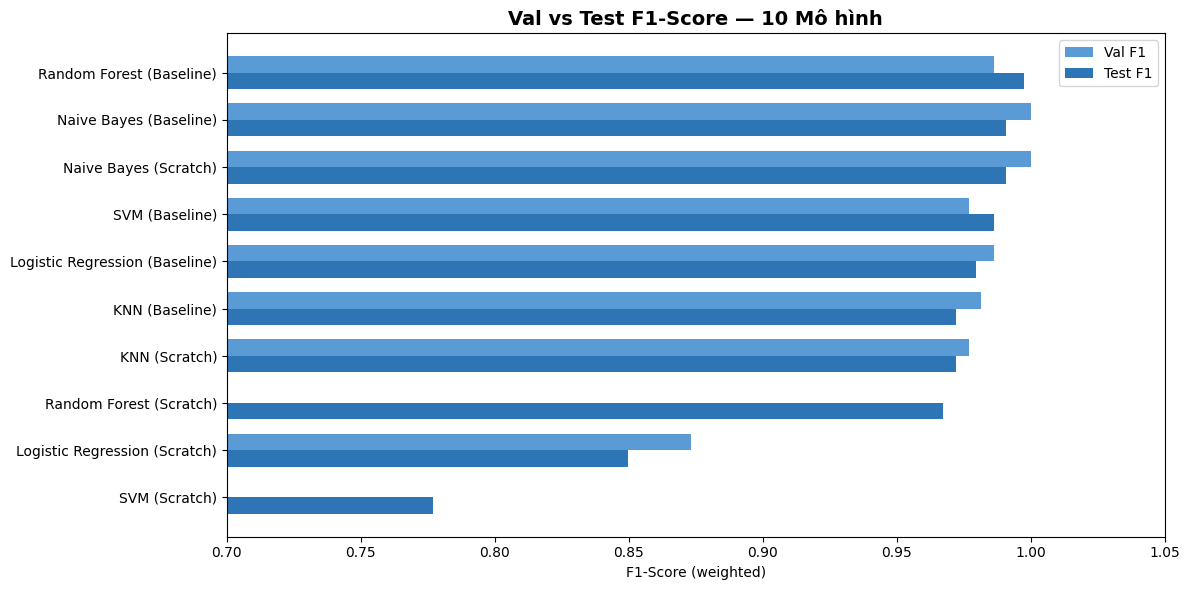

In [7]:
# --- 3c. Val vs Test F1-Score ---
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_all))
w = 0.35
ax.barh(x - w/2, df_all['Val F1'], w, label='Val F1', color='#5B9BD5')
ax.barh(x + w/2, df_all['Test F1'], w, label='Test F1', color='#2E75B6')
ax.set_yticks(x); ax.set_yticklabels(df_all['Model'])
ax.set_xlabel('F1-Score (weighted)'); ax.set_xlim(0.7, 1.05)
ax.set_title('Val vs Test F1-Score — 10 Mô hình', fontsize=14, fontweight='bold')
ax.legend(); ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 4. Chọn Best Model & Hyperparameter Tuning

**Random Forest (Baseline)** cho hiệu năng cao nhất → chọn để Tuning.

**Quy trình đúng:**
1. Tuning trên tập **Train** (GridSearchCV) → tìm tham số tốt nhất.
2. Gộp **Train + Val** → Retrain với tham số tốt nhất.
3. Đánh giá lần cuối trên **Test**.


In [8]:
# === Bước 1: GridSearchCV trên tập TRAIN ===
print("--- Bước 1: Hyperparameter Tuning trên tập Train ---")

rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy (Train): {grid_search.best_score_:.4f}")

val_pred_tuned = grid_search.best_estimator_.predict(X_val)
print(f"Validation Accuracy (best params): {accuracy_score(y_val, val_pred_tuned):.4f}")


--- Bước 1: Hyperparameter Tuning trên tập Train ---
Fitting 3 folds for each of 18 candidates, totalling 54 fits



Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy (Train): 0.9935
Validation Accuracy (best params): 0.9864


### Đánh giá hiệu quả của Hyperparameter Tuning

Xem mức độ cải thiện (Improvement) sau khi tuning so với mô hình mặc định (Baseline).

SO SÁNH HIỆU QUẢ TUNING TRÊN TẬP TEST (TRƯỚC KHI RETRAIN)
Accuracy mặc định (Baseline) : 0.9977
Accuracy sau khi Tuning      : 0.9977
------------------------------------------------------------
✅ Hiệu năng tăng thêm: +0.0027%


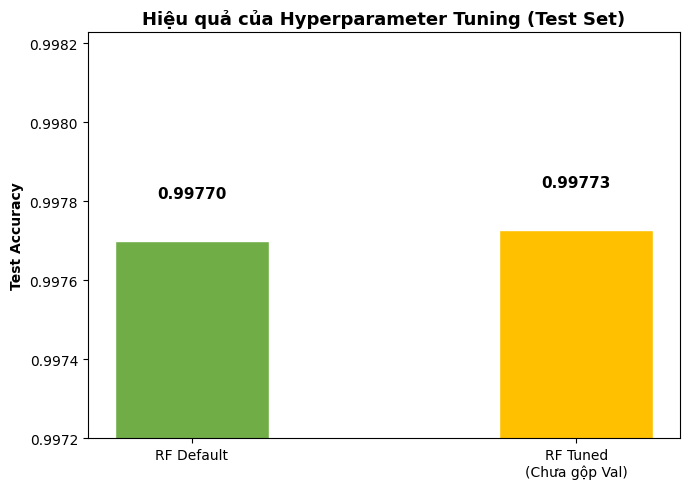

In [9]:
# Lấy điểm Accuracy mặc định của RF Baseline trên tập TEST từ bảng kết quả df_all
default_test_acc = df_all[(df_all['Model'] == 'Random Forest (Baseline)') & (df_all['Type'] == 'Library')]['Test Accuracy'].values[0]

# Dự đoán trên tập TEST bằng mô hình VỪA ĐƯỢC TUNE (chưa retrain với Val)
test_pred_tuned = grid_search.best_estimator_.predict(X_test)
tuned_test_acc = accuracy_score(y_test, test_pred_tuned)

improvement = (tuned_test_acc - default_test_acc) * 100

print("=" * 60)
print("SO SÁNH HIỆU QUẢ TUNING TRÊN TẬP TEST (TRƯỚC KHI RETRAIN)")
print("=" * 60)
print(f"Accuracy mặc định (Baseline) : {default_test_acc:.4f}")
print(f"Accuracy sau khi Tuning      : {tuned_test_acc:.4f}")
print("-" * 60)
if improvement > 0:
    print(f"✅ Hiệu năng tăng thêm: +{improvement:.4f}%")
elif improvement == 0:
    print("➖ Không thay đổi (Tham số mặc định đã tối ưu cho tập dữ liệu này)")
else:
    print(f"❌ Hiệu năng giảm đi: {improvement:.4f}%")
print("=" * 60)

# --- Vẽ biểu đồ so sánh ---
fig, ax = plt.subplots(figsize=(7, 5))
models_compare = ['RF Default', 'RF Tuned\n(Chưa gộp Val)']
acc_scores = [default_test_acc, tuned_test_acc]
colors = ['#70AD47', '#FFC000']

bars = ax.bar(models_compare, acc_scores, color=colors, width=0.4, edgecolor='white')
ax.set_ylim(min(acc_scores) - 0.0005, max(acc_scores) + 0.0005)
ax.set_ylabel('Test Accuracy', fontweight='bold')
ax.set_title('Hiệu quả của Hyperparameter Tuning (Test Set)', fontsize=13, fontweight='bold')

# Thêm nhãn giá trị trên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.0001, f'{yval:.5f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


## 5. Retrain trên Train + Val

Gộp tập Train và Validation, retrain với bộ tham số tốt nhất đã tìm được.


In [10]:
# === Bước 2: Gộp Train + Val → Retrain ===
X_full = np.concatenate([X_train, X_val])
y_full = np.concatenate([y_train, y_val])
print(f"Tập huấn luyện mới (Train + Val): {X_full.shape}")

best_params = grid_search.best_params_
print(f"Retrain với: {best_params}")

best_rf = RandomForestClassifier(random_state=42, **best_params)
t0 = time.time()
best_rf.fit(X_full, y_full)
print(f"Retrain hoàn tất — {time.time()-t0:.2f}s")


Tập huấn luyện mới (Train + Val): (1760, 13)
Retrain với: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


Retrain hoàn tất — 0.29s


## 6. Final Evaluation trên tập Test

In [11]:
y_pred_final = best_rf.predict(X_test)
final_acc  = accuracy_score(y_test, y_pred_final)
final_f1   = f1_score(y_test, y_pred_final, average='weighted')
final_prec = precision_score(y_test, y_pred_final, average='weighted')
final_rec  = recall_score(y_test, y_pred_final, average='weighted')

print("=" * 60)
print("  FINAL — Random Forest (Tuned + Retrained on Train+Val)")
print("=" * 60)
print(f"  Accuracy  : {final_acc:.4f}")
print(f"  F1-Score  : {final_f1:.4f}")
print(f"  Precision : {final_prec:.4f}")
print(f"  Recall    : {final_rec:.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))


  FINAL — Random Forest (Tuned + Retrained on Train+Val)
  Accuracy  : 0.9955
  F1-Score  : 0.9955
  Precision : 0.9957
  Recall    : 0.9955

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       0.95      1.00      0.98        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      0.95      0.97        20
          14       1.00 

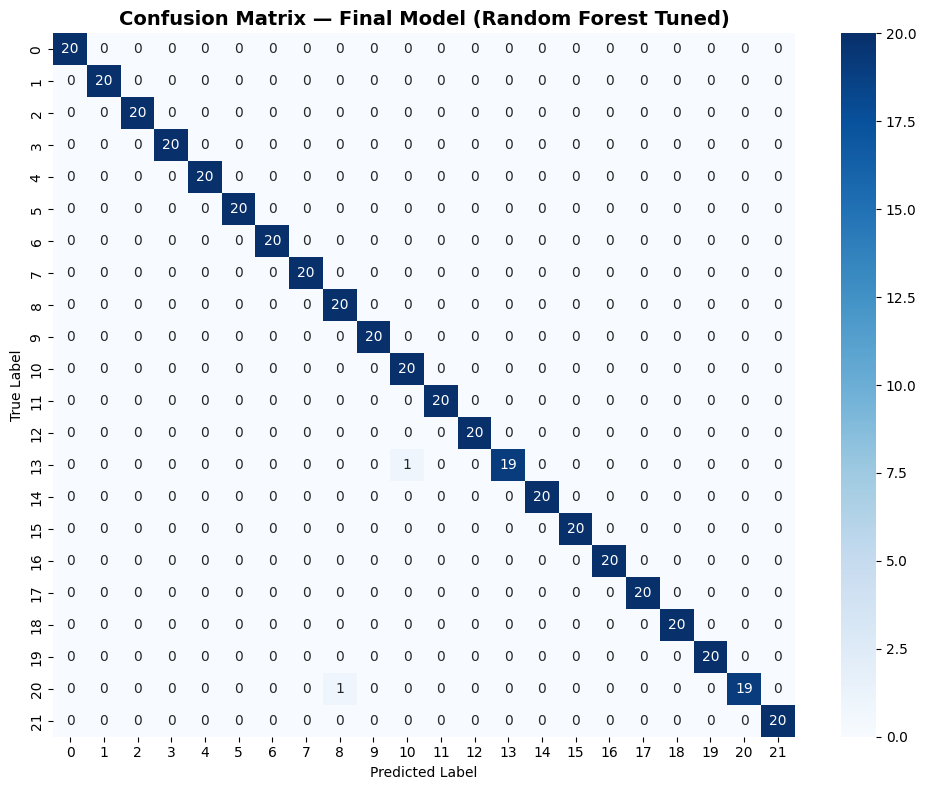

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Final Model (Random Forest Tuned)', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()


,Model,Type,Val Accuracy,Test Accuracy,Val F1,Test F1,Test Precision,Test Recall
0,Random Forest (Baseline),Library,0.9864,0.9977,0.9863,0.9977,0.9978,0.9977
1,⭐ RF (Tuned+Retrained),Final,0.9864,0.9955,0.9863,0.9955,0.9957,0.9955
2,Naive Bayes (Baseline),Library,1.0000,0.9909,1.0000,0.9909,0.9913,0.9909
3,Naive Bayes (Scratch),Scratch,1.0000,0.9909,1.0000,0.9909,0.9913,0.9909
4,SVM (Baseline),Library,0.9773,0.9864,0.9769,0.9863,0.9874,0.9864
5,Logistic Regression (Baseline),Library,0.9864,0.9795,0.9863,0.9795,0.9803,0.9795
6,KNN (Baseline),Library,0.9818,0.9727,0.9815,0.9722,0.9747,0.9727
7,KNN (Scratch),Scratch,0.9773,0.9727,0.9769,0.9723,0.9747,0.9727
8,Random Forest (Scratch),Scratch,0.6727,0.9682,0.6393,0.9674,0.9715,0.9682
9,Logistic Regression (Scratch),Scratch,0.8864,0.8636,0.8733,0.8498,0.8972,0.8636


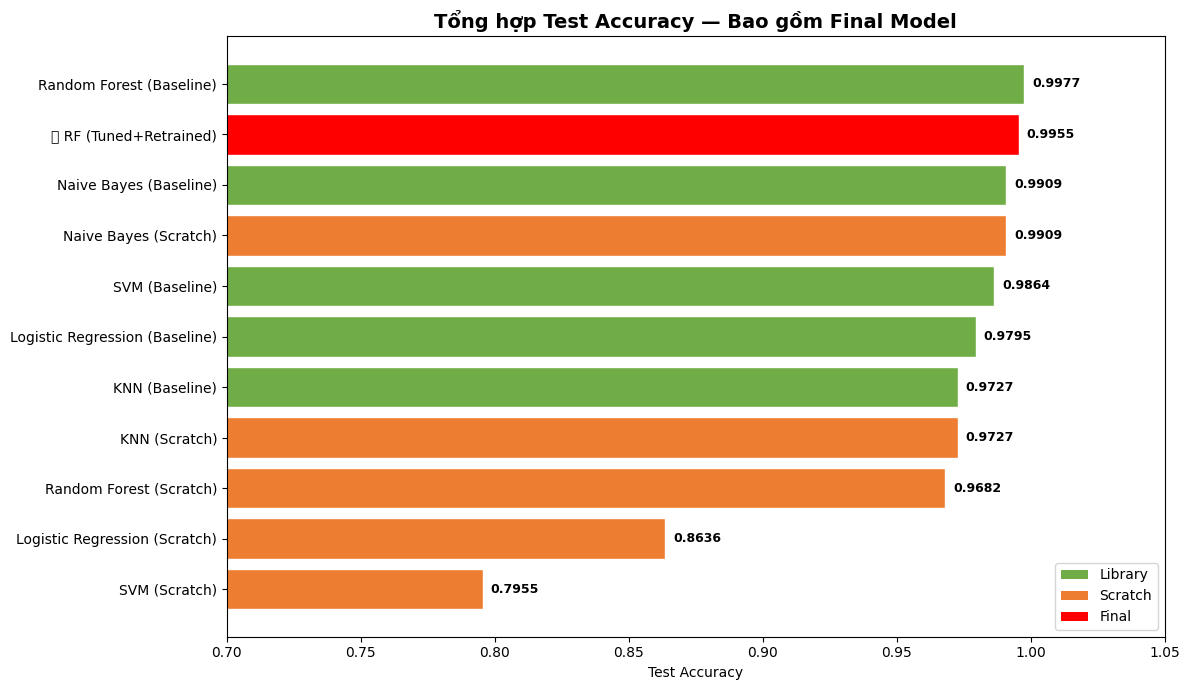

In [13]:
# So sánh Final Model với tất cả model khác
final_row = {
    'Model': '⭐ RF (Tuned+Retrained)', 'Type': 'Final',
    'Val Accuracy': round(accuracy_score(y_val, val_pred_tuned), 4),
    'Test Accuracy': round(final_acc, 4),
    'Val F1': round(f1_score(y_val, val_pred_tuned, average='weighted'), 4),
    'Test F1': round(final_f1, 4),
    'Test Precision': round(final_prec, 4),
    'Test Recall': round(final_rec, 4),
}
df_final = pd.concat([df_all, pd.DataFrame([final_row])], ignore_index=True)
df_final = df_final.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
display(df_final)

# Chart
fig, ax = plt.subplots(figsize=(12, 7))
color_map = {'Library': '#70AD47', 'Scratch': '#ED7D31', 'Final': '#FF0000'}
colors = [color_map[t] for t in df_final['Type']]
bars = ax.barh(df_final['Model'], df_final['Test Accuracy'], color=colors, edgecolor='white')
ax.set_xlabel('Test Accuracy')
ax.set_title('Tổng hợp Test Accuracy — Bao gồm Final Model', fontsize=14, fontweight='bold')
ax.set_xlim(0.7, 1.05); ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', ha='left', va='center', fontsize=9, fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in color_map.items()], loc='lower right')
plt.tight_layout()
plt.show()


## 7. Lưu mô hình tốt nhất

In [14]:
os.makedirs(MODELS_DIR, exist_ok=True)
model_path = os.path.join(MODELS_DIR, 'best_model.pkl')
joblib.dump(best_rf, model_path)
print(f"✅ Đã lưu mô hình tốt nhất vào: {model_path}")


✅ Đã lưu mô hình tốt nhất vào: ../saved_models/best_model.pkl
